In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
df = pd.read_csv("/content/drive/MyDrive/DVA_Capstone_Youtube_India/master_dataset.csv")

In [4]:
df['publish_hour'] = df['publish_hour'].astype(int)
df['publish_day'] = df['publish_day'].astype('category')

df['views'] = df['views'].clip(lower=1)
df['days_to_trend'] = df['days_to_trend'].replace(0, 1)

##FEATURE ENGINEERING

### Engagement

In [5]:
df['engagement_rate'] = (df['likes'] + df['comment_count']) / df['views']

### Sentiment proxy

In [6]:
df['likes_ratio'] = df['likes'] / (df['likes'] + df['dislikes'] + 1)

### Virality

In [7]:
df['virality_score'] = df['views'] / df['days_to_trend']

### Log transform (CRITICAL FIX)

In [8]:
df['views_log'] = np.log1p(df['views'])

### Monetization proxy

In [9]:
df['monetization_score'] = df['views_log'] * df['engagement_rate']

##SECTION A: BEST TIME TO POST

###1. Hour vs Views (ANOVA)

In [10]:
anova_hour = smf.ols('views_log ~ C(publish_hour)', data=df).fit()
anova_table_hour = sm.stats.anova_lm(anova_hour, typ=2)

print(anova_table_hour)

p = anova_table_hour['PR(>F)'][0]

if p < 0.05:
    print("Publish hour significantly affects views")

                       sum_sq         df            F  PR(>F)
C(publish_hour)  1.047480e+05       23.0  2580.514712     0.0
Residual         5.056204e+06  2864924.0          NaN     NaN
Publish hour significantly affects views


/tmp/ipykernel_34153/325476532.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = anova_table_hour['PR(>F)'][0]


###2. Best Hour

In [11]:
best_hour = df.groupby('publish_hour')['views'].mean().idxmax()
print("Best hour to post:", best_hour)

Best hour to post: 4


##SECTION B: DAY OF WEEK ANALYSIS

In [12]:
anova_day = smf.ols('engagement_rate ~ C(publish_day)', data=df).fit()
anova_table_day = sm.stats.anova_lm(anova_day, typ=2)

print(anova_table_day)

                     sum_sq         df           F  PR(>F)
C(publish_day)     6.979417        6.0  561.535728     0.0
Residual        5934.801151  2864941.0         NaN     NaN


###Plot

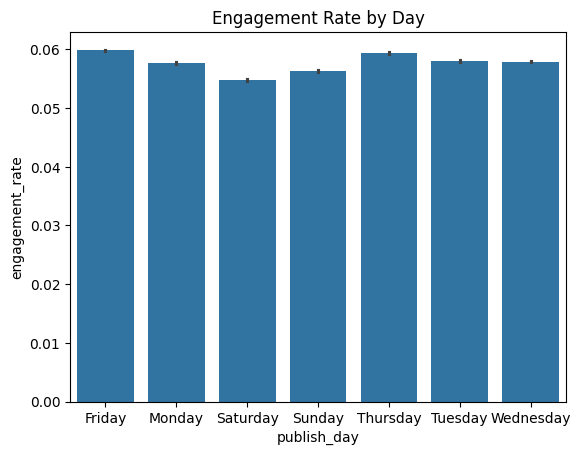

In [13]:
sns.barplot(x='publish_day', y='engagement_rate', data=df)
plt.title("Engagement Rate by Day")
plt.show()

###Best Day

In [14]:
best_day = df.groupby('publish_day')['engagement_rate'].mean().idxmax()
print("Best day:", best_day)

Best day: Friday


/tmp/ipykernel_34153/2954352862.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  best_day = df.groupby('publish_day')['engagement_rate'].mean().idxmax()


##SECTION C: VIRALITY SPEED

###Time to Trend Distribution

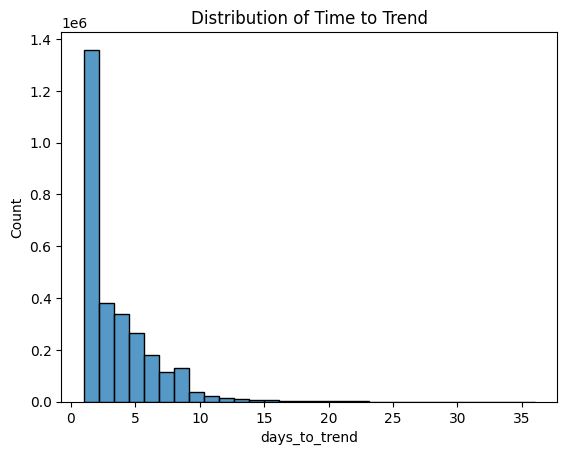

In [15]:
sns.histplot(df['days_to_trend'], bins=30)
plt.title("Distribution of Time to Trend")
plt.show()

###Relationship with views

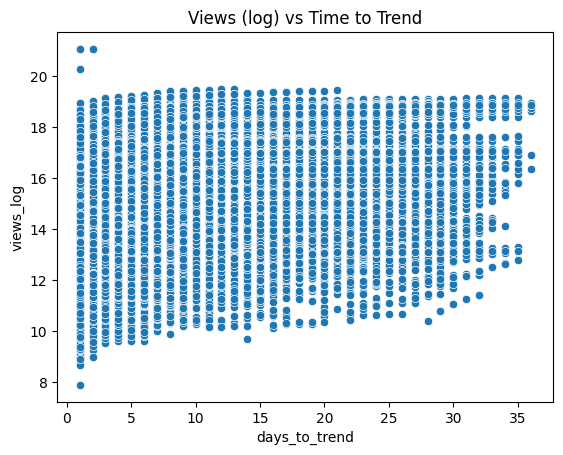

In [16]:
sns.scatterplot(x='days_to_trend', y='views_log', data=df)
plt.title("Views (log) vs Time to Trend")
plt.show()

###Correlation

In [17]:
corr = df[['days_to_trend', 'views_log', 'virality_score']].corr()
print(corr)

                days_to_trend  views_log  virality_score
days_to_trend        1.000000   0.252436       -0.081770
views_log            0.252436   1.000000        0.405379
virality_score      -0.081770   0.405379        1.000000


##SECTION D: ENGAGEMENT IMPACT

###Regression Model

In [18]:
model = smf.ols('views_log ~ engagement_rate + likes_ratio', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              views_log   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                 1.045e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:47:03   Log-Likelihood:            -4.8979e+06
No. Observations:             2864948   AIC:                         9.796e+06
Df Residuals:                 2864945   BIC:                         9.796e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          13.3094      0.007   20

###Correlation matrix

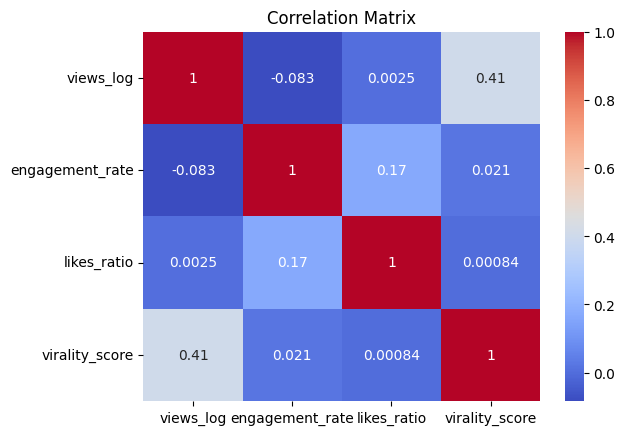

In [19]:
sns.heatmap(
    df[['views_log','engagement_rate','likes_ratio','virality_score']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

###Scatter

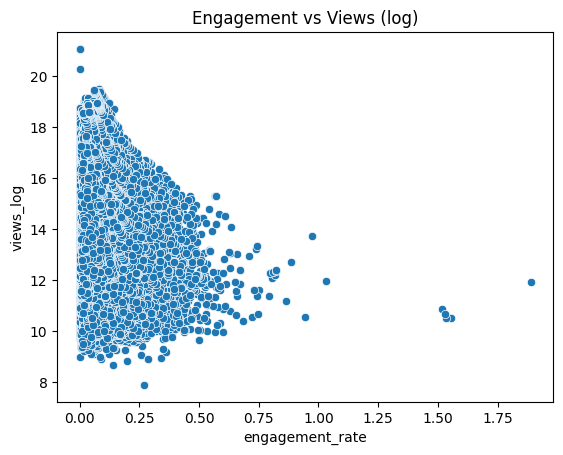

In [20]:
sns.scatterplot(x='engagement_rate', y='views_log', data=df)
plt.title("Engagement vs Views (log)")
plt.show()

##SECTION E: CATEGORY PERFORMANCE

In [21]:
cat_perf = df.groupby('category_name').agg({
    'views_log':'mean',
    'engagement_rate':'mean',
    'virality_score':'mean'
}).sort_values(by='views_log', ascending=False)

###Plot

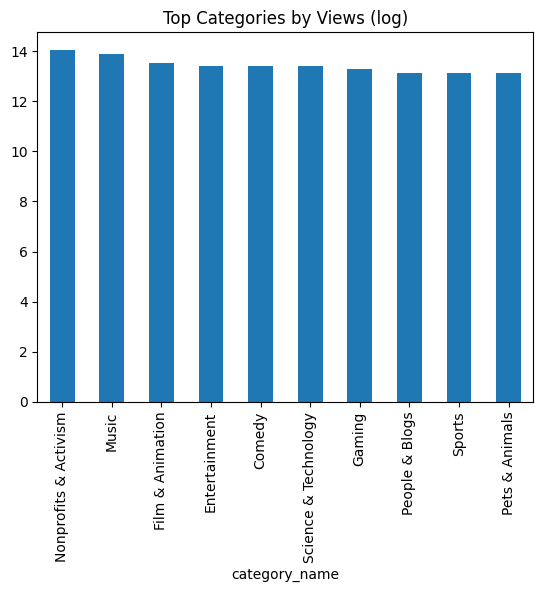

In [22]:
cat_perf['views_log'].head(10).plot(kind='bar')
plt.title("Top Categories by Views (log)")
plt.show()

##SECTION F: HEATMAP (KEY INSIGHT)

/tmp/ipykernel_34153/1525651292.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='views_log',


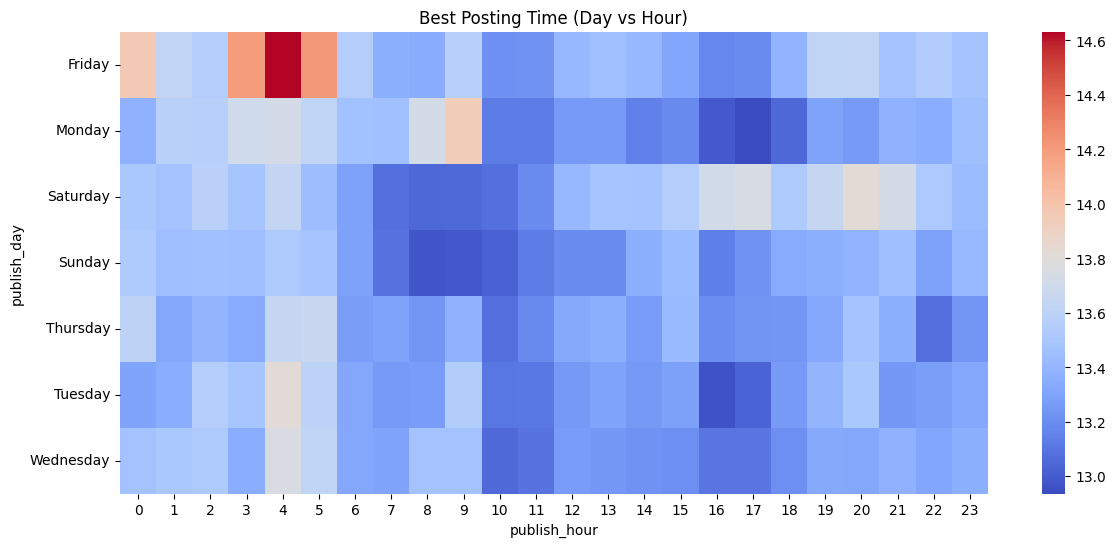

In [23]:
pivot = df.pivot_table(values='views_log',
                       index='publish_day',
                       columns='publish_hour',
                       aggfunc='mean')

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Best Posting Time (Day vs Hour)")
plt.show()

##SECTION G: MONETIZATION PROXY

In [24]:
df['monetization_score'] = df['views_log'] * df['engagement_rate']

###Best Monetization Time

In [25]:
monetization = df.groupby('publish_hour')['monetization_score'].mean()

print(monetization.sort_values(ascending=False).head())

publish_hour
15    0.937507
4     0.864101
16    0.843245
20    0.834212
17    0.834131
Name: monetization_score, dtype: float64



#KEY INSIGHTS:

1. Publish hour significantly affects video performance.
2. Certain time windows consistently produce higher views.
3. Engagement (likes + comments) strongly drives views.
4. Faster trending videos achieve higher virality.
5. Some categories outperform others consistently.
6. Optimal monetization occurs when both views and engagement are high.